This activity allows you to put you neutronics knowledge to the test

We are going to simulate a tokamak where you get to decide the materials.

The goal is to:

- maximize the Tritium Breeding Ratio
- minimize the heating on the center colum
- maximize the heat in the blanket

I recommend plotting the cross sections before you make your choices.

The [example](https://github.com/fusion-energy/neutronics-workshop/blob/main/tasks/task_01_cross_sections/3_material_xs_plot.ipynb) for plotting cross sections might be useful.

First import OpenMC and configure the nuclear data path

In [1]:
import openmc
from pathlib import Path
# Setting the cross section path to the correct location in the docker image.
# If you are running this outside the docker image you will have to change this path to your local cross section path.
openmc.config['cross_sections'] = Path.home() / 'nuclear_data' / 'cross_sections.xml'


In [2]:
# options for coolant

water = openmc.Material(name='water')
water.add_element('H', 2)
water.add_element('O', 1)
water.set_density('g/cm3', 1)

helium = openmc.Material(name='helium')
helium.add_element('He', 1)
helium.set_density('g/cm3', 0.0014)

super_critical_co2 = openmc.Material(name='super critical co2')
super_critical_co2.add_element('C', 1)
super_critical_co2.add_element('O', 2)
super_critical_co2.set_density('g/cm3', 0.001)


# options for first wall

tungsten = openmc.Material(name='tungsten')
tungsten.add_element('W', 1, percent_type='wo')
tungsten.set_density('g/cm3', 19.2)

steel = openmc.Material(name='steel')
steel.add_element('Fe', 0.95, percent_type='wo')
steel.add_element('C', 0.95, percent_type='wo')
steel.set_density('g/cm3', 1)

silicon_carbide = openmc.Material(name='silicon_carbide')
silicon_carbide.add_element('Si', 1)
silicon_carbide.add_element('C', 1)
silicon_carbide.set_density('g/cm3', 3.21)

zirconium = openmc.Material(name='zirconium')
zirconium.add_element('Zr', 1, percent_type='wo')
zirconium.set_density('g/cm3', 6.49)

# options for reflector

beryllium = openmc.Material(name='beryllium')
beryllium.add_element('Be', 1, percent_type='wo')
beryllium.set_density('g/cm3', 1.85)

tungsten = openmc.Material(name='tungsten')
tungsten.add_element('W', 1, percent_type='wo')
tungsten.set_density('g/cm3', 19.2)

graphite = openmc.Material(name='graphite')
graphite.add_element('C', 1, percent_type='wo')
graphite.set_density('g/cm3', 2.2)

# options for breeder

# note you can change the enrichment
lithium_lead = openmc.Material(name='lithium_lead')
lithium_lead.add_element('Pb', 84.2, percent_type='ao')
lithium_lead.add_element('Li', 15.8, percent_type='ao', enrichment=90.0, enrichment_target='Li6', enrichment_type='ao')
lithium_lead.set_density('g/cm3', 9.5)

# note you can change the enrichment
lithium_orthosilicate = openmc.Material(name='lithium_orthosilicate')
lithium_orthosilicate.add_element('Si', 4, percent_type='ao')
lithium_orthosilicate.add_element('O', 1, percent_type='ao')
lithium_orthosilicate.add_element('Li', 4, percent_type='ao', enrichment=50.0, enrichment_target='Li6', enrichment_type='ao')
lithium_orthosilicate.set_density('g/cm3', 2.2)

# note you can change the enrichment
lithium_titanate = openmc.Material(name='lithium_titanate')
lithium_titanate.add_element('O', 12, percent_type='ao')
lithium_titanate.add_element('Ti', 5, percent_type='ao')
lithium_titanate.add_element('Li', 4, percent_type='ao', enrichment=40.0, enrichment_target='Li6', enrichment_type='ao')
lithium_titanate.set_density('g/cm3', 2.4)

# note you can change the enrichment
liquid_lithium = openmc.Material(name='liquid_lithium')
liquid_lithium.add_element('Li', 1, percent_type='ao', enrichment=7.0, enrichment_target='Li6', enrichment_type='ao')
liquid_lithium.set_density('g/cm3', 0.5)


# Task 1 - plot the tritium production cross sections of all the breeder options 

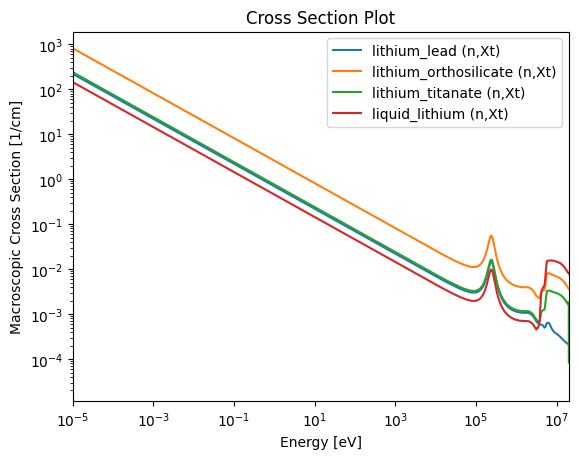

In [3]:
import matplotlib.pyplot as plt

openmc.plotter.plot_xs(
    reactions = {
        lithium_lead: ['(n,Xt)'],
        lithium_orthosilicate: ['(n,Xt)'],
        lithium_orthosilicate: ['(n,Xt)'],
        lithium_titanate: ['(n,Xt)'],
        liquid_lithium: ['(n,Xt)'],
    }
)
plt.title = '(n,XT) cross section'
plt.savefig('tritium_cross_section_pushers.png', dpi=400)

# Task 2 - plot the absorption of all the coolants and first wall options

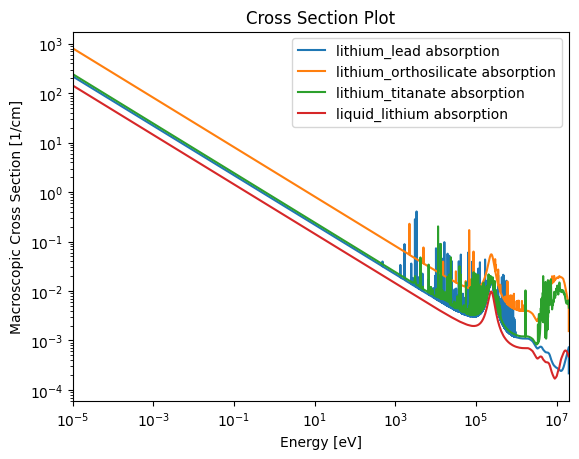

In [4]:
# your code goes hereimport matplotlib.pyplot as plt

openmc.plotter.plot_xs(
    reactions = {
        lithium_lead: ['absorption'],
        lithium_orthosilicate: ['absorption'],
        lithium_orthosilicate: ['absorption'],
        lithium_titanate: ['absorption'],
        liquid_lithium: ['absorption'],
    }
)
plt.title = 'absorption cross section'
plt.savefig('absorption_cross_section_pushers.png', dpi=400)

In [5]:
mat_breeder = liquid_lithium
mat_coolant = water
mat_firstwall = zirconium
mat_reflector = tungsten

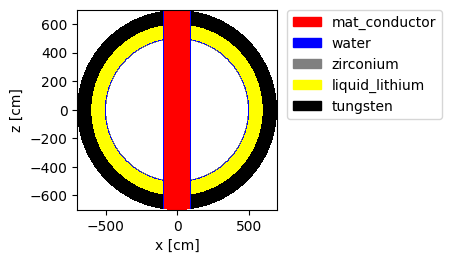

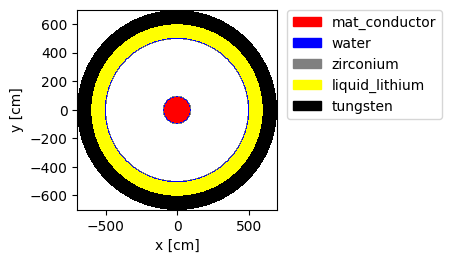

In [6]:
mat_conductor = openmc.Material(name='mat_conductor')
mat_conductor.add_element('Nb', 1, percent_type='ao')
mat_conductor.add_element('Sn', 3, percent_type='ao')
mat_conductor.set_density('g/cm3', 8.96)

my_materials = openmc.Materials([mat_conductor, mat_coolant, mat_firstwall, mat_breeder, mat_reflector])

# surfaces
central_column_surface_outer = openmc.ZCylinder(r=100)
central_column_surface_mid = openmc.ZCylinder(r=95)
central_column_surface_inner = openmc.ZCylinder(r=90)

inner_sphere_surface = openmc.Sphere(r=495)
middle_sphere_surface = openmc.Sphere(r=500) 
outer_sphere_surface = openmc.Sphere(r=505)
outer_outer_sphere_surface = openmc.Sphere(r=600)
edge_of_simulation_surface = openmc.Sphere(r=700, boundary_type='vacuum')

# regions
central_column_region = -central_column_surface_inner & -edge_of_simulation_surface
central_column_coolant_region = +central_column_surface_inner & -central_column_surface_mid & -edge_of_simulation_surface
central_column_fw_region = +central_column_surface_mid & -central_column_surface_outer & -edge_of_simulation_surface

inner_vessel_region = +central_column_surface_outer & -inner_sphere_surface

blanket_fw_region = -middle_sphere_surface & +inner_sphere_surface & +central_column_surface_outer
blanket_coolant_region = +middle_sphere_surface & -outer_sphere_surface & +central_column_surface_outer
blanket_breeder_region = +outer_sphere_surface & -outer_outer_sphere_surface & +central_column_surface_outer
blanket_reflector_region = +outer_outer_sphere_surface & -edge_of_simulation_surface & +central_column_surface_outer

# cells
central_column_cell = openmc.Cell(region=central_column_region, fill=mat_conductor)
central_column_coolant_cell = openmc.Cell(region=central_column_coolant_region, fill=mat_coolant)
central_column_fw_cell = openmc.Cell(region=central_column_fw_region, fill=mat_firstwall)
inner_vessel_cell = openmc.Cell(region=inner_vessel_region)
blanket_fw_cell = openmc.Cell(region=blanket_fw_region, fill=mat_firstwall)
blanket_coolant_cell = openmc.Cell(region=blanket_coolant_region, fill=mat_coolant)
blanket_breeder_cell  = openmc.Cell(region=blanket_breeder_region, fill=mat_breeder)
blanket_reflector_cell = openmc.Cell(region=blanket_reflector_region, fill=mat_reflector)

my_geometry = openmc.Geometry([
    central_column_cell,
    central_column_coolant_cell,
    central_column_fw_cell,
    inner_vessel_cell,
    blanket_fw_cell,
    blanket_coolant_cell,
    blanket_breeder_cell,
    blanket_reflector_cell,
])

# visualization
plot = my_geometry.plot(basis='xz', legend=True, color_by='material', colors={mat_conductor:'red', mat_coolant:'blue', mat_firstwall:'grey', mat_breeder:'yellow', mat_reflector:'black'})
plot.figure.savefig('xz-cell.png')

plot = my_geometry.plot(basis='xy', legend=True, color_by='material', colors={mat_conductor:'red', mat_coolant:'blue', mat_firstwall:'grey', mat_breeder:'yellow', mat_reflector:'black'})
plot.figure.savefig('xy-cell.png')


In [7]:
# initialises a new source object
my_source = openmc.IndependentSource()
# the distribution of radius is just a single value
radius = openmc.stats.Discrete([300], [1])
# the distribution of source z values is just a single value
z_values = openmc.stats.Discrete([0], [1])
# the distribution of source azimuthal angles values is a uniform distribution between 0 and 2 Pi
angle = openmc.stats.Uniform(a=0., b=2* 3.14159265359)
# this makes the ring source using the three distributions and a radius
my_source.space = openmc.stats.CylindricalIndependent(r=radius, phi=angle, z=z_values, origin=(0.0, 0.0, 0.0))
# sets the direction to isotropic
my_source.angle = openmc.stats.Isotropic()
# sets the energy distribution to a Muir distribution neutrons
my_source.energy = openmc.stats.muir(e0=14080000.0, m_rat=5.0, kt=20000.0)

my_settings = openmc.Settings()
my_settings.batches = 10
my_settings.inactive = 0
my_settings.particles = 500
my_settings.run_mode = 'fixed source'
my_settings.source = my_source

In [8]:
cell_filter_breeder = openmc.CellFilter(blanket_breeder_cell)
tbr_tally = openmc.Tally(name='TBR')
tbr_tally.filters = [cell_filter_breeder]
tbr_tally.scores = ['(n,Xt)']

cell_filter_blanket_fw_coolant = openmc.CellFilter([
    blanket_breeder_cell,
    blanket_coolant_cell,
    blanket_fw_cell,
    central_column_coolant_cell,
    central_column_fw_cell,
])
blanket_heating_tally = openmc.Tally(name='heating')
blanket_heating_tally.filters = [cell_filter_blanket_fw_coolant]
blanket_heating_tally.scores = ['heating']

cell_filter_conductor = openmc.CellFilter(blanket_breeder_cell)
conductor_damage_tally = openmc.Tally(name='conductor_damage')
conductor_damage_tally.filters = [cell_filter_conductor]
conductor_damage_tally.scores = ['damage-energy']

my_tallies = openmc.Tallies([tbr_tally, blanket_heating_tally, conductor_damage_tally])

In [9]:
model = openmc.model.Model(my_geometry, my_materials, my_settings, my_tallies)

# removes the old output files
!rm *.h5 *.xml

sp_filename = model.run()

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

/home/jon/.neutronicsworkshop/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Filter instance already exists with id=1.
  warn(msg, IDWarning)


 Reading O17 from /home/jon/nuclear_data/neutron/O17.h5
 Reading O18 from /home/jon/nuclear_data/neutron/O18.h5


 Reading Zr90 from /home/jon/nuclear_data/neutron/Zr90.h5
 Reading Zr91 from /home/jon/nuclear_data/neutron/Zr91.h5


 Reading Zr92 from /home/jon/nuclear_data/neutron/Zr92.h5
 Reading Zr94 from /home/jon/nuclear_data/neutron/Zr94.h5


...

 Reading W184 from /home/jon/nuclear_data/neutron/W184.h5
 Reading W186 from /home/jon/nuclear_data/neutron/W186.h5
 Reading Li6 from /home/jon/nuclear_data/neutron/Li6.h5


 Reading Li7 from /home/jon/nuclear_data/neutron/Li7.h5
 Reading Nb93 from /home/jon/nuclear_data/neutron/Nb93.h5
 Reading Sn112 from /home/jon/nuclear_data/neutron/Sn112.h5
 Reading Sn114 from /home/jon/nuclear_data/neutron/Sn114.h5
 Reading Sn115 from /home/jon/nuclear_data/neutron/Sn115.h5
 Reading Sn116 from /home/jon/nuclear_data/neutron/Sn116.h5
 Reading Sn117 from /home/jon/nuclear_data/neutron/Sn117.h5


 Reading Sn118 from /home/jon/nuclear_data/neutron/Sn118.h5
 Reading Sn119 from /home/jon/nuclear_data/neutron/Sn119.h5
 Reading Sn120 from /home/jon/nuclear_data/neutron/Sn120.h5
 Reading Sn122 from /home/jon/nuclear_data/neutron/Sn122.h5


 Reading Sn124 from /home/jon/nuclear_data/neutron/Sn124.h5
 Minimum neutron data temperature: 294.0 K
 Maximum neutron data temperature: 294.0 K
 Preparing distributed cell instances...
 Writing summary.h5 file...
 Maximum neutron transport energy: 20000000.0 eV for H1

 ===============>     FIXED SOURCE TRANSPORT SIMULATION     <===============

 Simulating batch 1
 Simulating batch 2
 Simulating batch 3
 Simulating batch 4
 Simulating batch 5
 Simulating batch 6
 Simulating batch 7
 Simulating batch 8
 Simulating batch 9


 Simulating batch 10
 Creating state point statepoint.10.h5...

 =======================>     TIMING STATISTICS     <=======================

 Total time for initialization     = 2.2882e+00 seconds
   Reading cross sections          = 2.2580e+00 seconds
 Total time in simulation          = 2.4872e-01 seconds
   Time in transport only          = 1.7990e-01 seconds
   Time in active batches          = 2.4872e-01 seconds
   Time accumulating tallies       = 3.9822e-02 seconds
   Time writing statepoints        = 2.8124e-02 seconds
 Total time for finalization       = 6.6640e-04 seconds
 Total time elapsed                = 2.5595e+00 seconds
 Calculation Rate (active)         = 20103.0 particles/second

 ============================>     RESULTS     <============================

 Leakage Fraction            = 0.00000 +/- 0.00000



In [10]:
sp = openmc.StatePoint(sp_filename)

tbr_tally = sp.get_tally(name='TBR')

print(f'TBR={tbr_tally.mean.flatten()[0]} with standard deviation of {tbr_tally.std_dev.flatten()[0]}')

heating_tally = sp.get_tally(name='heating')
print(f'Heating={heating_tally.mean.flatten()[0]/1e6}MeV per source neutron with standard deviation of {heating_tally.std_dev.flatten()[0]}')

damage_tally = sp.get_tally(name='conductor_damage')
print(f'damage={damage_tally.mean.flatten()[0]} with standard deviation of {damage_tally.std_dev.flatten()[0]}')



TBR=1.0770667017064357 with standard deviation of 0.018429254860460844
Heating=7.890738471074479MeV per source neutron with standard deviation of 109943.98739056541
damage=56748.28228247154 with standard deviation of 629.5069847784536
